<a href="https://colab.research.google.com/github/io-uty/skt-pytorch/blob/main/%EC%A0%84%EC%9D%B4%ED%95%99%EC%8A%B5_%EA%B8%B0%EB%B0%98_%EC%BB%B4%ED%93%A8%ED%84%B0_%EB%B9%84%EC%A0%84_%EB%B6%84%EB%A5%98_Ants_vs_Bees.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. 실행 환경, 난수 고정, 장치 설정


- set_seed() : 실험을 재현 가능하게 만들기 위해 모든 무작위성의 원천을 고정
- get_default_device() : CUDA → MPS → CPU 순으로 가능한 최적의 디바이스를 방어적으로(에러 안 나게) 자동 탐색

In [ ]:
from __future__ import annotations

import os
import platform
import random
import sys
import time
import urllib.request
import zipfile
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Iterable, List, Tuple

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms
from torchvision.utils import make_grid

try:
    from torch.utils.tensorboard import SummaryWriter
    TENSORBOARD_AVAILABLE = True
except Exception as tensorboard_import_error:
    SummaryWriter = None
    TENSORBOARD_AVAILABLE = False

#난수 고정
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

#device 설정
def get_default_device() -> torch.device:
    if hasattr(torch, "accelerator"):
        try:
            if torch.accelerator.is_available():
                accelerator = torch.accelerator.current_accelerator()
                accelerator_name = accelerator.type if hasattr(accelerator, "type") else str(accelerator)
                return torch.device(accelerator_name)
        except Exception:
            pass
    if torch.cuda.is_available():
        return torch.device("cuda")
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


def check_runtime_prerequisites() -> None:
    checks = {
        "torch import": torch.__version__ is not None,
        "torchvision import": torchvision.__version__ is not None,
        "ResNet18 weights enum": hasattr(models, "ResNet18_Weights"),
        "ImageFolder": hasattr(datasets, "ImageFolder"),
        "Normalize transform": hasattr(transforms, "Normalize"),
    }
    failed = [name for name, ok in checks.items() if not ok]
    if failed:
        raise RuntimeError(f"Runtime prerequisite check failed: {failed}")

    dummy_model = models.resnet18(weights=None)
    dummy_model.fc = nn.Linear(dummy_model.fc.in_features, 2)
    dummy_model.eval()
    dummy_inputs = torch.randn(2, 3, 224, 224)
    with torch.no_grad():
        dummy_logits = dummy_model(dummy_inputs)
    assert tuple(dummy_logits.shape) == (2, 2), tuple(dummy_logits.shape)
    del dummy_model, dummy_inputs, dummy_logits

#난수설정
SEED = 42
set_seed(SEED) # 재현성(Reproducibility) 확보

IN_COLAB = "google.colab" in sys.modules
device = get_default_device()
PROJECT_DIR = Path("/content") if IN_COLAB else Path.cwd()
DATA_ROOT = PROJECT_DIR / "data"
DATA_DIR = DATA_ROOT / "hymenoptera_data"
CHECKPOINT_DIR = PROJECT_DIR / "checkpoints"
RUNS_DIR = PROJECT_DIR / "runs" / "transfer_learning_lecture"

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
RUNS_DIR.mkdir(parents=True, exist_ok=True)

check_runtime_prerequisites()

print(f"Python version: {platform.python_version()}")
print(f"PyTorch version: {torch.__version__}")
print(f"torchvision version: {torchvision.__version__}")
print(f"Colab runtime: {IN_COLAB}")
print(f"Device: {device}")
print(f"TensorBoard available: {TENSORBOARD_AVAILABLE}")
print(f"Project directory: {PROJECT_DIR}")

if device.type == "cpu":
    print("GPU runtime is not enabled. The notebook remains executable, but training will be slower on CPU.")

Python version: 3.12.13
PyTorch version: 2.11.0+cu128
torchvision version: 0.26.0+cu128
Colab runtime: True
Device: cuda
TensorBoard available: True
Project directory: /content


# 2. 데이터셋 다운로드

In [ ]:
DATA_URL = "https://download.pytorch.org/tutorial/hymenoptera_data.zip"
ZIP_PATH = DATA_ROOT / "hymenoptera_data.zip"


def download_and_extract_hymenoptera(
    url: str = DATA_URL,
    data_root: Path = DATA_ROOT,
    data_dir: Path = DATA_DIR,
    zip_path: Path = ZIP_PATH,
) -> Path:
    data_root.mkdir(parents=True, exist_ok=True)
    if data_dir.exists():
        print(f"Dataset already exists: {data_dir}")
        return data_dir

    print(f"Downloading dataset from {url}")
    urllib.request.urlretrieve(url, zip_path)

    print(f"Extracting dataset to {data_root}")
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(data_root)

    if not data_dir.exists():
        raise FileNotFoundError(f"Expected dataset directory not found: {data_dir}")
    return data_dir


data_dir = download_and_extract_hymenoptera()

for split in ["train", "val"]:
    split_dir = data_dir / split
    print(f"\n[{split}]")
    for class_dir in sorted(split_dir.iterdir()):
        if class_dir.is_dir():
            num_images = sum(1 for path in class_dir.iterdir() if path.is_file())
            print(f"  {class_dir.name:>5}: {num_images:3d} images")

Extracting dataset to /content/data

[train]
   ants: 124 images
   bees: 121 images

[val]
   ants:  70 images
   bees:  83 images


# 3. 전처리 및 augmentation
- ImageNet 정규화 값 (이미 배운 내용의 재사용) 사용
- Train용 전처리 — Data Augmentation(데이터 증강) 목적
  - 과적합 줄임

- val용 전처리 — 일관성(Consistency) 목적 (test)

  

In [ ]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

BATCH_SIZE = 4
NUM_WORKERS = 2 if os.name != "nt" else 0
PIN_MEMORY = device.type == "cuda"


data_transforms = {
    # train용 전처리 : data Augmentation 목적
    "train": transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]),
    # Val용 전처리 : 일관성 목적
    "val": transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD), # 데이터 정규화
    ]),
}

image_datasets = {
    split: datasets.ImageFolder(str(data_dir / split), data_transforms[split])
    for split in ["train", "val"]
}

dataloaders = {
    split: DataLoader(
        image_datasets[split],
        batch_size=BATCH_SIZE,
        shuffle=(split == "train"),
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
    )
    for split in ["train", "val"]
}

dataset_sizes = {split: len(image_datasets[split]) for split in ["train", "val"]}
class_names = image_datasets["train"].classes
num_classes = len(class_names)

print(f"Class names: {class_names}")
print(f"Class-to-index mapping: {image_datasets['train'].class_to_idx}")
print(f"Dataset sizes: {dataset_sizes}")
print(f"Batch size: {BATCH_SIZE}")

Class names: ['ants', 'bees']
Class-to-index mapping: {'ants': 0, 'bees': 1}
Dataset sizes: {'train': 244, 'val': 153}
Batch size: 4


# 4. Dataset과 DataLoader의 출력 형태 확인


In [ ]:
inputs, labels = next(iter(dataloaders["train"]))

print(f"inputs.shape: {tuple(inputs.shape)}")
print(f"inputs.dtype: {inputs.dtype}")
print(f"labels.shape: {tuple(labels.shape)}")
print(f"labels.dtype: {labels.dtype}")
print(f"label indices: {labels.tolist()}")
print(f"label names: {[class_names[index] for index in labels.tolist()]}")
print(f"normalized input range: min={inputs.min().item():.3f}, max={inputs.max().item():.3f}")

inputs.shape: (4, 3, 224, 224)
inputs.dtype: torch.float32
labels.shape: (4,)
labels.dtype: torch.int64
label indices: [1, 1, 0, 0]
label names: ['bees', 'bees', 'ants', 'ants']
normalized input range: min=-2.118, max=2.640


# 5. 정규화 역변환과 mini-batch 시각화

- 화면에 보여주기 전에, 정규화했던 수식을 반대로 계산해서 원래 범위(0~1)로 되돌려야 함


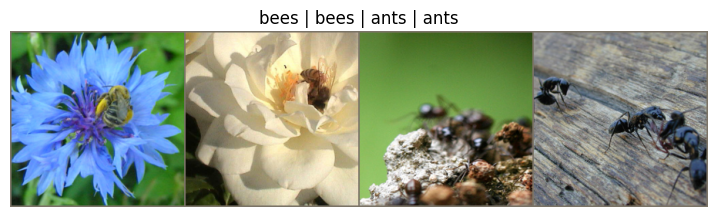

In [ ]:

# 정규화의 역연산
def denormalize(tensor: torch.Tensor, mean: List[float] = IMAGENET_MEAN, std: List[float] = IMAGENET_STD) -> torch.Tensor:
    mean_tensor = torch.tensor(mean, dtype=tensor.dtype, device=tensor.device).view(-1, 1, 1)
    std_tensor = torch.tensor(std, dtype=tensor.dtype, device=tensor.device).view(-1, 1, 1)
    return tensor * std_tensor + mean_tensor

# 실제로 화면에 그리는 함수
def imshow_tensor(image_tensor: torch.Tensor, title: str | List[str] | None = None) -> None:
    image_tensor = denormalize(image_tensor.detach().cpu()).clamp(0, 1) # 강제로 범위 0~1로
    np_image = image_tensor.numpy().transpose((1, 2, 0))
    plt.figure(figsize=(9, 5))
    plt.imshow(np_image)
    if title is not None:
        if isinstance(title, list):
            title = " | ".join(title)
        plt.title(title)
    plt.axis("off")
    plt.show()


batch_grid = make_grid(inputs, nrow=BATCH_SIZE)
imshow_tensor(batch_grid, title=[class_names[index] for index in labels.tolist()])

# 6. ResNet-18 기반 classifier 구성
- 어떤 레이어를 학습시키고 어떤 레이어를 고정(freeze)할지를 다루는 부분


In [ ]:
# 파라미터 개수 세기
def count_parameters(model: nn.Module) -> Dict[str, int]:
    total = sum(param.numel() for param in model.parameters())
    trainable = sum(param.numel() for param in model.parameters() if param.requires_grad)
    # requires_grad = True : 학습 중 업데이트 되는 파라미터 (trainable)
    # False면 그라디언트 계산 및 업데이트하지 않음
    frozen = total - trainable # 전체에서 학습 가능한 것 빼고 고정된 것의 개수
    return {"total": total, "trainable": trainable, "frozen": frozen}


def summarize_parameters(model: nn.Module, max_rows: int = 20) -> None:
    rows = []
    for name, param in model.named_parameters():
        rows.append((name, tuple(param.shape), param.numel(), param.requires_grad))

    counts = count_parameters(model)
    print(f"Total parameters    : {counts['total']:,}")
    print(f"Trainable parameters: {counts['trainable']:,}")
    print(f"Frozen parameters   : {counts['frozen']:,}")
    print("\nParameter tensors")
    print(f"{'name':45s} {'shape':22s} {'numel':>12s} {'trainable':>10s}")
    print("-" * 95)
    for name, shape, numel, trainable in rows[:max_rows]:
        print(f"{name:45s} {str(shape):22s} {numel:12,d} {str(trainable):>10s}")
    if len(rows) > max_rows:
        print(f"... {len(rows) - max_rows} more parameter tensors")

# 핵심 함수
def build_resnet18_classifier(num_classes: int, fine_tune: bool = True) -> Tuple[nn.Module, models.ResNet18_Weights]:
    # 사전학습 가중치 설정
    weights = models.ResNet18_Weights.IMAGENET1K_V1
    model = models.resnet18(weights=weights)

    #fine_tune 여부에 따른 분기
    #False면 기존 레이어를 전부 freeze함 -> 그라디언트 계산 및 업데이트 하지 않음
    if not fine_tune:
        for param in model.parameters():
            param.requires_grad = torch._functionalize_inductor_storage_resized_counter

    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    return model, weights


model_shape, resnet18_weights = build_resnet18_classifier(num_classes=num_classes, fine_tune=True)
print(resnet18_weights)
print(f"New classifier: {model_shape.fc}")
summarize_parameters(model_shape, max_rows=12)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 242MB/s]


ResNet18_Weights.IMAGENET1K_V1
New classifier: Linear(in_features=512, out_features=2, bias=True)
Total parameters    : 11,177,538
Trainable parameters: 11,177,538
Frozen parameters   : 0

Parameter tensors
name                                          shape                         numel  trainable
-----------------------------------------------------------------------------------------------
conv1.weight                                  (64, 3, 7, 7)                 9,408       True
bn1.weight                                    (64,)                            64       True
bn1.bias                                      (64,)                            64       True
layer1.0.conv1.weight                         (64, 64, 3, 3)               36,864       True
layer1.0.bn1.weight                           (64,)                            64       True
layer1.0.bn1.bias                             (64,)                            64       True
layer1.0.conv2.weight                         

# 7. Forward pass shape 점검

In [ ]:
def collect_forward_shapes(
    model: nn.Module,
    sample_batch: torch.Tensor,
    target_modules: Iterable[str] | None = None,
) -> Tuple[List[Dict[str, object]], torch.Tensor]:
    if target_modules is None:
        target_modules = ["conv1", "bn1", "relu", "maxpool", "layer1", "layer2", "layer3", "layer4", "avgpool", "fc"]

    records: List[Dict[str, object]] = []
    handles = []
    modules = dict(model.named_modules())

    def make_hook(name: str):
        def hook(module: nn.Module, module_input: Tuple[torch.Tensor, ...], module_output: torch.Tensor) -> None:
            input_shape = tuple(module_input[0].shape) if module_input else None
            if isinstance(module_output, torch.Tensor):
                output_shape = tuple(module_output.shape)
            elif isinstance(module_output, (list, tuple)) and len(module_output) > 0 and isinstance(module_output[0], torch.Tensor):
                output_shape = tuple(module_output[0].shape)
            else:
                output_shape = type(module_output).__name__
            records.append({"module": name, "input": input_shape, "output": output_shape})
        return hook

    for name in target_modules:
        if name not in modules:
            raise KeyError(f"Module not found: {name}")
        handles.append(modules[name].register_forward_hook(make_hook(name)))

    model = model.to(device)
    model.eval()
    with torch.no_grad():
        logits = model(sample_batch.to(device, non_blocking=PIN_MEMORY))

    for handle in handles:
        handle.remove()

    return records, logits


shape_records, sample_logits = collect_forward_shapes(model_shape, inputs)
print(f"Final logits shape: {tuple(sample_logits.shape)}")
print(f"Final logits dtype : {sample_logits.dtype}")
print("\nForward shape table")
print(f"{'module':10s} {'input':24s} {'output':24s}")
print("-" * 62)
for record in shape_records:
    print(f"{record['module']:10s} {str(record['input']):24s} {str(record['output']):24s}")

del model_shape
if device.type == "cuda":
    torch.cuda.empty_cache()

Final logits shape: (4, 2)
Final logits dtype : torch.float32

Forward shape table
module     input                    output                  
--------------------------------------------------------------
conv1      (4, 3, 224, 224)         (4, 64, 112, 112)       
bn1        (4, 64, 112, 112)        (4, 64, 112, 112)       
relu       (4, 64, 112, 112)        (4, 64, 112, 112)       
maxpool    (4, 64, 112, 112)        (4, 64, 56, 56)         
layer1     (4, 64, 56, 56)          (4, 64, 56, 56)         
layer2     (4, 64, 56, 56)          (4, 128, 28, 28)        
layer3     (4, 128, 28, 28)         (4, 256, 14, 14)        
layer4     (4, 256, 14, 14)         (4, 512, 7, 7)          
avgpool    (4, 512, 7, 7)           (4, 512, 1, 1)          
fc         (4, 512)                 (4, 2)                  


# 8. 손실 함수, optimizer, scheduler, autograd

In [ ]:
@dataclass # __init__ 직접 안써도 지정 필드를 자동으로 받는 생성자를 만들어줌
class PhaseMetrics:
    loss: float
    acc: float

# 현재 learning rate 조회
def get_current_lr(optimizer: optim.Optimizer) -> float:
    return float(optimizer.param_groups[0]["lr"])

# 버전 호환성 고려
def safe_load_state_dict(path: Path, map_location: torch.device | str) -> Dict[str, torch.Tensor]:
    try:
        return torch.load(path, map_location=map_location, weights_only=True)
    except TypeError:
        return torch.load(path, map_location=map_location)


def train_one_epoch(
    model: nn.Module,
    dataloader: DataLoader,
    criterion: nn.Module,
    optimizer: optim.Optimizer,
    device: torch.device,
) -> PhaseMetrics:
    model.train() # 변수들 초기화
    running_loss = 0.0
    running_corrects = 0
    num_samples = len(dataloader.dataset)

    for inputs_batch, labels_batch in dataloader:
        inputs_batch = inputs_batch.to(device, non_blocking=PIN_MEMORY)
        labels_batch = labels_batch.to(device, non_blocking=PIN_MEMORY)

        # gradient를 None으로 설정하면 메모리 할당 자체를 생략, 최적화 가능
        optimizer.zero_grad(set_to_none=True)
        outputs = model(inputs_batch)
        loss = criterion(outputs, labels_batch)
        loss.backward()
        optimizer.step()

        preds = outputs.argmax(dim=1)
        running_loss += loss.item() * inputs_batch.size(0)
        # 정확한 epoch 전체 평균을 구하려면, 이 배치의 평균 loss × 이 배치의 샘플 수로
        # 다시 합계로 되돌린 다음, 나중에 전체 샘플 수로 나눠야 정확함
        # 따라서 inputs_batch.size(0) 을 곱함
        running_corrects += (preds == labels_batch).sum().item() # 정확도 누적

    epoch_loss = running_loss / num_samples
    epoch_acc = running_corrects / num_samples
    return PhaseMetrics(loss=epoch_loss, acc=epoch_acc)


#검증단계
@torch.no_grad()
def evaluate(
    model: nn.Module,
    dataloader: DataLoader,
    criterion: nn.Module,
    device: torch.device,
) -> PhaseMetrics:
    model.eval()
    running_loss = 0.0
    running_corrects = 0
    num_samples = len(dataloader.dataset)

    for inputs_batch, labels_batch in dataloader:
        inputs_batch = inputs_batch.to(device, non_blocking=PIN_MEMORY)
        labels_batch = labels_batch.to(device, non_blocking=PIN_MEMORY)

        outputs = model(inputs_batch)
        loss = criterion(outputs, labels_batch)
        preds = outputs.argmax(dim=1)

        running_loss += loss.item() * inputs_batch.size(0)
        running_corrects += (preds == labels_batch).sum().item()

    epoch_loss = running_loss / num_samples
    epoch_acc = running_corrects / num_samples
    return PhaseMetrics(loss=epoch_loss, acc=epoch_acc)


def fit_model(
    model: nn.Module,
    dataloaders: Dict[str, DataLoader],
    criterion: nn.Module,
    optimizer: optim.Optimizer,
    scheduler: lr_scheduler.LRScheduler,
    device: torch.device,
    num_epochs: int,
    checkpoint_path: Path,
    run_name: str,
) -> Tuple[nn.Module, List[Dict[str, float]]]:
# 초기 설정
    since = time.time()
    checkpoint_path.parent.mkdir(parents=True, exist_ok=True)
    model = model.to(device)

    writer = None
    if TENSORBOARD_AVAILABLE:
        writer = SummaryWriter(log_dir=str(RUNS_DIR / run_name))

    best_acc = -1.0
    torch.save(model.state_dict(), checkpoint_path)
    history: List[Dict[str, float]] = []

    for epoch in range(1, num_epochs + 1):
        lr_before_step = get_current_lr(optimizer)
        train_metrics = train_one_epoch(model, dataloaders["train"], criterion, optimizer, device)
        val_metrics = evaluate(model, dataloaders["val"], criterion, device)

        if val_metrics.acc > best_acc:
            best_acc = val_metrics.acc
            torch.save(model.state_dict(), checkpoint_path)

        row = {
            "epoch": float(epoch),
            "lr": lr_before_step,
            "train_loss": train_metrics.loss,
            "train_acc": train_metrics.acc,
            "val_loss": val_metrics.loss,
            "val_acc": val_metrics.acc,
        }
        history.append(row)

        if writer is not None:
            writer.add_scalars("loss", {"train": train_metrics.loss, "val": val_metrics.loss}, epoch)
            writer.add_scalars("accuracy", {"train": train_metrics.acc, "val": val_metrics.acc}, epoch)
            writer.add_scalar("learning_rate", lr_before_step, epoch)

        print(
            f"Epoch {epoch:02d}/{num_epochs:02d} | "
            f"lr={lr_before_step:.6f} | "
            f"train loss={train_metrics.loss:.4f}, acc={train_metrics.acc:.4f} | "
            f"val loss={val_metrics.loss:.4f}, acc={val_metrics.acc:.4f}"
        )

        scheduler.step()

    if writer is not None:
        writer.close()

    elapsed = time.time() - since
    print(f"Training complete in {elapsed // 60:.0f}m {elapsed % 60:.0f}s")
    print(f"Best validation accuracy: {best_acc:.4f}")

    best_state_dict = safe_load_state_dict(checkpoint_path, map_location=device)
    model.load_state_dict(best_state_dict)
    return model, history

# 9.  Metric 기록과 시각화 함수

In [ ]:
def plot_history(history: List[Dict[str, float]], title: str) -> None:
    epochs = [int(item["epoch"]) for item in history]

    plt.figure(figsize=(7, 4))
    plt.plot(epochs, [item["train_loss"] for item in history], marker="o", label="train")
    plt.plot(epochs, [item["val_loss"] for item in history], marker="o", label="val")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title}: loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(epochs, [item["train_acc"] for item in history], marker="o", label="train")
    plt.plot(epochs, [item["val_acc"] for item in history], marker="o", label="val")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title}: accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()


def summarize_history(history: List[Dict[str, float]], name: str) -> Dict[str, float | str]:
    best_epoch = max(history, key=lambda item: item["val_acc"])
    final_epoch = history[-1]
    return {
        "name": name,
        "best_epoch": best_epoch["epoch"],
        "best_val_acc": best_epoch["val_acc"],
        "final_train_acc": final_epoch["train_acc"],
        "final_val_acc": final_epoch["val_acc"],
    }

# 10. TensorBoard 로그 구성

In [ ]:
print(f"TensorBoard logging enabled: {TENSORBOARD_AVAILABLE}")
print(f"Log directory: {RUNS_DIR}")

TensorBoard logging enabled: True
Log directory: /content/runs/transfer_learning_lecture


# 11. 실험 1: 사전학습 ConvNet 전체 fine-tuning


Fine-tuning model parameter summary
Total parameters    : 11,177,538
Trainable parameters: 11,177,538
Frozen parameters   : 0

Parameter tensors
name                                          shape                         numel  trainable
-----------------------------------------------------------------------------------------------
conv1.weight                                  (64, 3, 7, 7)                 9,408       True
bn1.weight                                    (64,)                            64       True
bn1.bias                                      (64,)                            64       True
layer1.0.conv1.weight                         (64, 64, 3, 3)               36,864       True
layer1.0.bn1.weight                           (64,)                            64       True
layer1.0.bn1.bias                             (64,)                            64       True
layer1.0.conv2.weight                         (64, 64, 3, 3)               36,864       True
layer1.0.bn2.we

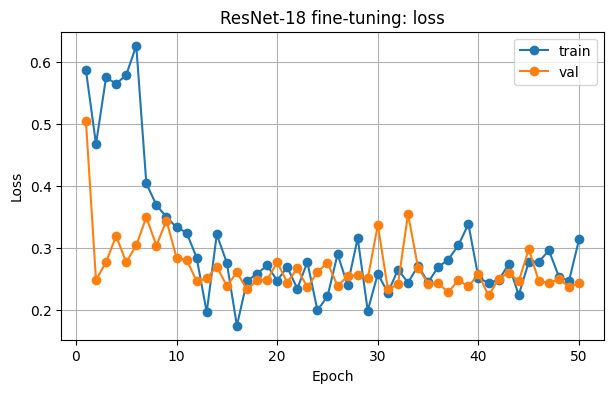

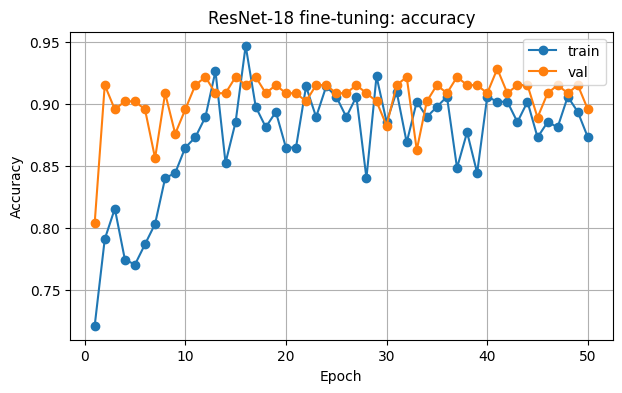

In [ ]:
NUM_EPOCHS = 50

model_ft, _ = build_resnet18_classifier(num_classes=num_classes, fine_tune=True)
model_ft = model_ft.to(device)

criterion = nn.CrossEntropyLoss()
optimizer_ft = optim.SGD(model_ft.parameters(), lr=0.001, momentum=0.9)
scheduler_ft = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

print("Fine-tuning model parameter summary")
summarize_parameters(model_ft, max_rows=12)

model_ft, history_ft = fit_model(
    model=model_ft,
    dataloaders=dataloaders,
    criterion=criterion,
    optimizer=optimizer_ft,
    scheduler=scheduler_ft,
    device=device,
    num_epochs=NUM_EPOCHS,
    checkpoint_path=CHECKPOINT_DIR / "resnet18_finetuning_best.pt",
    run_name="resnet18_finetuning",
)

plot_history(history_ft, title="ResNet-18 fine-tuning")

# 12. Fine-tuning 결과 시각화

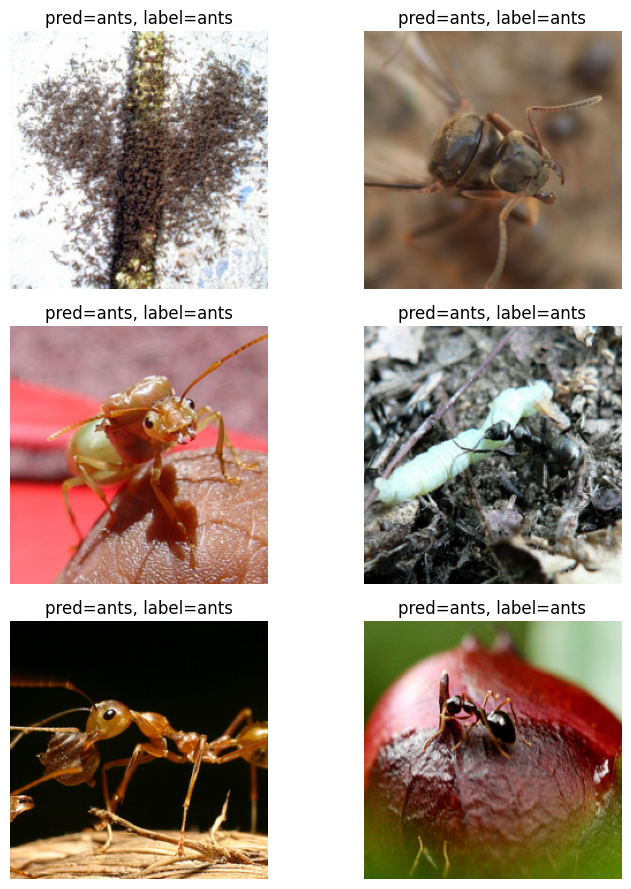

In [ ]:
def visualize_model_predictions(
    model: nn.Module,
    dataloader: DataLoader,
    class_names: List[str],
    num_images: int = 6,
) -> None:
    model.eval()
    images_so_far = 0
    rows = int(np.ceil(num_images / 2))
    cols = 2
    plt.figure(figsize=(8, 3 * rows))

    with torch.no_grad():
        for inputs_batch, labels_batch in dataloader:
            inputs_batch = inputs_batch.to(device, non_blocking=PIN_MEMORY)
            labels_batch = labels_batch.to(device, non_blocking=PIN_MEMORY)
            outputs = model(inputs_batch)
            preds = outputs.argmax(dim=1)

            for j in range(inputs_batch.size(0)):
                images_so_far += 1
                ax = plt.subplot(rows, cols, images_so_far)
                ax.axis("off")
                predicted = class_names[preds[j].item()]
                actual = class_names[labels_batch[j].item()]
                ax.set_title(f"pred={predicted}, label={actual}")
                image_to_show = denormalize(inputs_batch[j].detach().cpu()).clamp(0, 1)
                ax.imshow(image_to_show.numpy().transpose((1, 2, 0)))

                if images_so_far == num_images:
                    plt.tight_layout()
                    plt.show()
                    return

    plt.tight_layout()
    plt.show()


visualize_model_predictions(model_ft, dataloaders["val"], class_names, num_images=6)

# 13. 실험 2: 고정 feature extractor 방식

Fixed feature extractor parameter summary
Total parameters    : 11,177,538
Trainable parameters: 1,026
Frozen parameters   : 11,176,512

Parameter tensors
name                                          shape                         numel  trainable
-----------------------------------------------------------------------------------------------
conv1.weight                                  (64, 3, 7, 7)                 9,408      False
bn1.weight                                    (64,)                            64      False
bn1.bias                                      (64,)                            64      False
layer1.0.conv1.weight                         (64, 64, 3, 3)               36,864      False
layer1.0.bn1.weight                           (64,)                            64      False
layer1.0.bn1.bias                             (64,)                            64      False
layer1.0.conv2.weight                         (64, 64, 3, 3)               36,864      False
layer

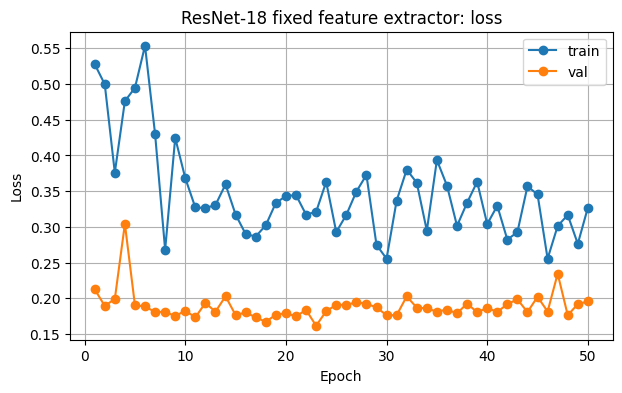

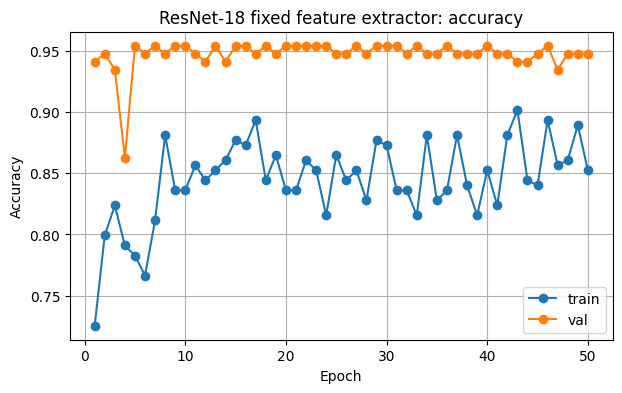

In [ ]:
model_conv, _ = build_resnet18_classifier(num_classes=num_classes, fine_tune=False)
model_conv = model_conv.to(device)

criterion = nn.CrossEntropyLoss()
optimizer_conv = optim.SGD(model_conv.fc.parameters(), lr=0.001, momentum=0.9)
scheduler_conv = lr_scheduler.StepLR(optimizer_conv, step_size=7, gamma=0.1)

print("Fixed feature extractor parameter summary")
summarize_parameters(model_conv, max_rows=12)

model_conv, history_conv = fit_model(
    model=model_conv,
    dataloaders=dataloaders,
    criterion=criterion,
    optimizer=optimizer_conv,
    scheduler=scheduler_conv,
    device=device,
    num_epochs=NUM_EPOCHS,
    checkpoint_path=CHECKPOINT_DIR / "resnet18_fixed_feature_best.pt",
    run_name="resnet18_fixed_feature",
)

plot_history(history_conv, title="ResNet-18 fixed feature extractor")

# 14. Fixed feature extractor 결과 시각화

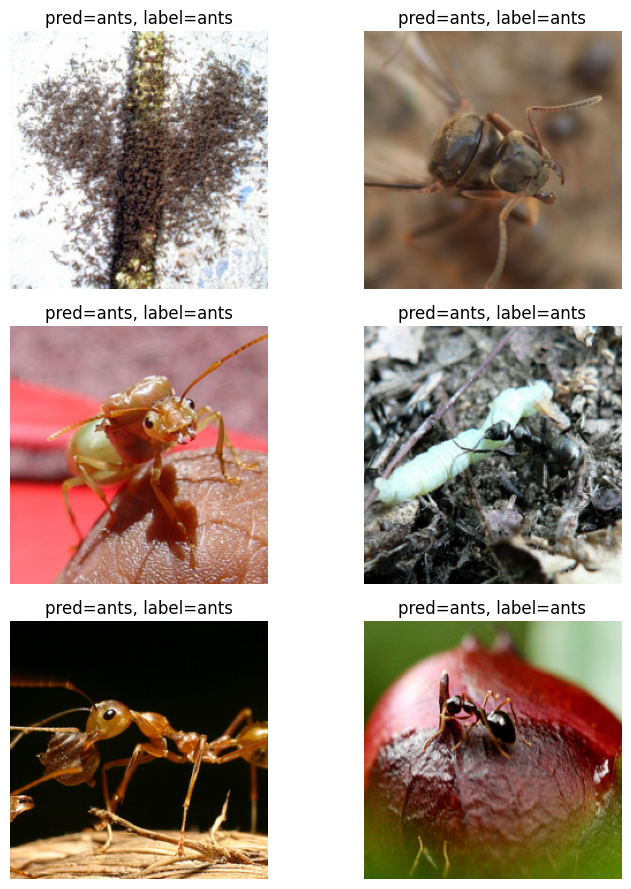

In [ ]:
visualize_model_predictions(model_conv, dataloaders["val"], class_names, num_images=6)

# 15. 두 전이학습 방식의 metric 비교

In [ ]:
comparison_rows = [
    summarize_history(history_ft, "fine_tuning"),
    summarize_history(history_conv, "fixed_feature"),
]

print(f"{'name':18s} {'best_epoch':>10s} {'best_val_acc':>14s} {'final_train_acc':>16s} {'final_val_acc':>14s}")
print("-" * 78)
for row in comparison_rows:
    print(
        f"{row['name']:18s} "
        f"{row['best_epoch']:10.0f} "
        f"{row['best_val_acc']:14.4f} "
        f"{row['final_train_acc']:16.4f} "
        f"{row['final_val_acc']:14.4f}"
    )

name               best_epoch   best_val_acc  final_train_acc  final_val_acc
------------------------------------------------------------------------------
fine_tuning                41         0.9281           0.8730         0.8954
fixed_feature               5         0.9542           0.8525         0.9477


# 16. `state_dict` 기반 저장과 복원

In [ ]:
STATE_DICT_PATH = CHECKPOINT_DIR / "resnet18_fixed_feature_state_dict.pt"
torch.save(model_conv.state_dict(), STATE_DICT_PATH)
print(f"Saved state_dict to: {STATE_DICT_PATH}")

restored_model, _ = build_resnet18_classifier(num_classes=num_classes, fine_tune=False)
restored_state_dict = safe_load_state_dict(STATE_DICT_PATH, map_location=device)
restored_model.load_state_dict(restored_state_dict)
restored_model = restored_model.to(device)
restored_model.eval()
model_conv.eval()

with torch.no_grad():
    sample_inputs = inputs.to(device, non_blocking=PIN_MEMORY)
    original_logits = model_conv(sample_inputs)
    restored_logits = restored_model(sample_inputs)
    max_abs_diff = (original_logits - restored_logits).abs().max().item()

print(f"Maximum absolute difference between logits: {max_abs_diff:.8f}")

Saved state_dict to: /content/checkpoints/resnet18_fixed_feature_state_dict.pt
Maximum absolute difference between logits: 0.00000000


# 17. 단일 이미지 추론


{'image_path': '/content/data/hymenoptera_data/val/bees/456097971_860949c4fc.jpg', 'input_shape': (1, 3, 224, 224), 'predicted_label': 'bees', 'predicted_probability': 0.9902430176734924, 'logits': [-3.5831518173217773, 1.0368118286132812]}


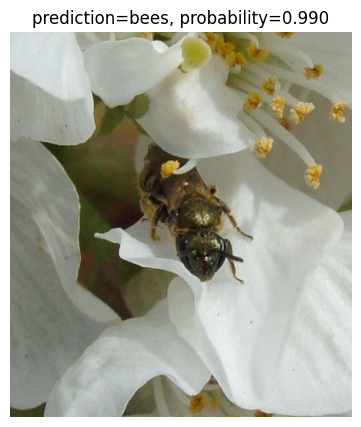

In [ ]:
@torch.no_grad()
def predict_image(
    model: nn.Module,
    image_path: Path,
    transform: transforms.Compose,
    class_names: List[str],
    device: torch.device,
) -> Dict[str, object]:
    model.eval()
    image = Image.open(image_path).convert("RGB")
    input_tensor = transform(image).unsqueeze(0).to(device)
    logits = model(input_tensor)
    probabilities = torch.softmax(logits, dim=1)
    predicted_index = int(probabilities.argmax(dim=1).item())
    return {
        "image_path": str(image_path),
        "input_shape": tuple(input_tensor.shape),
        "predicted_label": class_names[predicted_index],
        "predicted_probability": float(probabilities[0, predicted_index].item()),
        "logits": logits.detach().cpu().squeeze(0).tolist(),
    }


sample_image_path = next((DATA_DIR / "val" / "bees").glob("*.jpg"))
prediction = predict_image(restored_model, sample_image_path, data_transforms["val"], class_names, device)
print(prediction)

original_image = Image.open(sample_image_path).convert("RGB")
plt.figure(figsize=(5, 5))
plt.imshow(original_image)
plt.title(f"prediction={prediction['predicted_label']}, probability={prediction['predicted_probability']:.3f}")
plt.axis("off")
plt.show()

# 18. 확장 실험 1: 부분 fine-tuning


In [ ]:
def build_resnet18_partial_finetune(
    num_classes: int,
    trainable_prefixes: Tuple[str, ...] = ("layer4", "fc"),
) -> nn.Module:
    model, _ = build_resnet18_classifier(num_classes=num_classes, fine_tune=True)
    for name, param in model.named_parameters():
        param.requires_grad = any(name.startswith(prefix) for prefix in trainable_prefixes)
    return model


def run_partial_finetuning_experiment(num_epochs: int = 10) -> Tuple[nn.Module, List[Dict[str, float]]]:
    model_partial = build_resnet18_partial_finetune(num_classes=num_classes)
    model_partial = model_partial.to(device)
    trainable_parameters = [param for param in model_partial.parameters() if param.requires_grad]
    optimizer_partial = optim.SGD(trainable_parameters, lr=0.001, momentum=0.9)
    scheduler_partial = lr_scheduler.StepLR(optimizer_partial, step_size=7, gamma=0.1)
    summarize_parameters(model_partial, max_rows=20)
    return fit_model(
        model=model_partial,
        dataloaders=dataloaders,
        criterion=nn.CrossEntropyLoss(),
        optimizer=optimizer_partial,
        scheduler=scheduler_partial,
        device=device,
        num_epochs=num_epochs,
        checkpoint_path=CHECKPOINT_DIR / "resnet18_partial_finetuning_best.pt",
        run_name="resnet18_partial_finetuning",
    )


print("Defined: run_partial_finetuning_experiment(num_epochs=10)")

Defined: run_partial_finetuning_experiment(num_epochs=10)


# 19. 확장 실험 2: label smoothing과 class probability calibration


In [ ]:
def run_label_smoothing_experiment(
    num_epochs: int = 10,
    label_smoothing: float = 0.1,
) -> Tuple[nn.Module, List[Dict[str, float]]]:
    model_smooth, _ = build_resnet18_classifier(num_classes=num_classes, fine_tune=False)
    model_smooth = model_smooth.to(device)
    optimizer_smooth = optim.SGD(model_smooth.fc.parameters(), lr=0.001, momentum=0.9)
    scheduler_smooth = lr_scheduler.StepLR(optimizer_smooth, step_size=7, gamma=0.1)
    criterion_smooth = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    summarize_parameters(model_smooth, max_rows=12)
    return fit_model(
        model=model_smooth,
        dataloaders=dataloaders,
        criterion=criterion_smooth,
        optimizer=optimizer_smooth,
        scheduler=scheduler_smooth,
        device=device,
        num_epochs=num_epochs,
        checkpoint_path=CHECKPOINT_DIR / "resnet18_fixed_feature_label_smoothing_best.pt",
        run_name="resnet18_fixed_feature_label_smoothing",
    )


print("Defined: run_label_smoothing_experiment(num_epochs=10, label_smoothing=0.1)")

Defined: run_label_smoothing_experiment(num_epochs=10, label_smoothing=0.1)


# 20. 확장 실험 3: pretrained weights transform 사용 비교


In [ ]:
def evaluate_with_weights_transform(model: nn.Module, weights: models.ResNet18_Weights) -> PhaseMetrics:
    weights_val_transform = weights.transforms()
    val_dataset_with_weights_transform = datasets.ImageFolder(str(DATA_DIR / "val"), weights_val_transform)
    val_loader_with_weights_transform = DataLoader(
        val_dataset_with_weights_transform,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
    )
    return evaluate(model, val_loader_with_weights_transform, nn.CrossEntropyLoss(), device)


weights_transform_metrics = evaluate_with_weights_transform(restored_model, resnet18_weights)
print(f"Validation loss with weights.transforms(): {weights_transform_metrics.loss:.4f}")
print(f"Validation accuracy with weights.transforms(): {weights_transform_metrics.acc:.4f}")

Validation loss with weights.transforms(): 0.1903
Validation accuracy with weights.transforms(): 0.9542
